# Addressing peer reviews

In this notebook we will use code to answer to the reviews obtained by the peer-review system.

## Retrieving best model
First we need to retrieve the best model to be able to get the accuracy per barcode and check the attention weights.

In [1]:
import numpy as np
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

2025-04-24 07:33:25.908204: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-24 07:33:26.410942: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


After running ShowAccuracy.py on the GPU with our container we get this output:

../../results/NewNN/Ablation/20240503_11-42-14_FinalLR1E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.030026549473404884, 0.9913243651390076]
Validation  : [0.03592557832598686, 0.986358106136322]
Test : [0.19601191580295563, 0.954965353012085]
../../results/NewNN/Ablation/20240503_11-43-30_FinalLR1E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.04372193291783333, 0.9863389134407043]
Validation  : [0.057527847588062286, 0.9811205863952637]
Test : [0.1767975389957428, 0.956986129283905]
../../results/NewNN/Ablation/20240503_11-43-50_FinalLR1E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.04334758222103119, 0.9871123433113098]
Validation  : [0.0533052459359169, 0.9833130240440369]
Test : [0.18823425471782684, 0.956986129283905]
../../results/NewNN/Ablation/20240503_11-51-02_FinalLR2E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.029812674969434738, 0.9897401928901672]
Validation  : [0.04180384799838066, 0.9873325228691101]
Test : [0.1808346062898636, 0.957274854183197]
../../results/NewNN/Ablation/20240503_12-05-49_FinalLR2E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.022611744701862335, 0.9937751889228821]
Validation  : [0.025851359590888023, 0.9912301898002625]
Test : [0.2196020483970642, 0.9546766877174377]
../../results/NewNN/Ablation/20240503_13-10-14_FinalLR2E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.03708413988351822, 0.9883796572685242]
Validation  : [0.04767124727368355, 0.985018253326416]
Test : [0.18380998075008392, 0.9584295749664307]
../../results/NewNN/Ablation/20240503_16-13-15_FinalLR5E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.028121011331677437, 0.9919300675392151]
Validation  : [0.03644905611872673, 0.9890377521514893]
Test : [0.19330722093582153, 0.9578521847724915]
../../results/NewNN/Ablation/20240506_14-50-01_FinalLR2E4_BestModel.keras
       [ loss , accuracy ]
Train: [0.038283731788396835, 0.9875223636627197]
Validation  : [0.046881433576345444, 0.9848964810371399]
Test : [0.20399388670921326, 0.954965353012085]

Therefore, the file that contains our best model is actually  ../../results/NewNN/Ablation/20240503_13-10-14_FinalLR2E4_BestModel.keras with a test accuracy of 0.9584295749664307. We will use this model to compute the accuracies of each barcode

## Finding per barcode accuracy
With the best model, we predict the labels with the script observing....py. The results are saved in the results section and here we compare:

In [15]:
y_est=np.load("../../results/PeerReview/y_est.npy")
y_true_onehot=np.load("../../results/PeerReview/y_true.npy") #One hot encoding
y_true=np.argwhere(y_true_onehot==1)[:,1] #reformat
print(np.sum(y_true==y_est)/len(y_true)) #We observe the mentioned accuracy.

0.9584295612009238


In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

In [16]:
n_labels=8; #8 barcodes.
conf_matrix=np.zeros((n_labels,n_labels))
for true_barcode in range(n_labels):
    predictions=y_est[y_true==true_barcode]; #For this barcode gets the predictions
    for pred_barcode in range(n_labels):
        conf_matrix[true_barcode,pred_barcode] = np.sum(predictions==pred_barcode)/len(predictions);

In [17]:
conf_matrix

array([[0.95652174, 0.02766798, 0.01185771, 0.        , 0.00395257,
        0.        , 0.        , 0.        ],
       [0.00398406, 0.94223108, 0.        , 0.0438247 , 0.00398406,
        0.0059761 , 0.        , 0.        ],
       [0.03960396, 0.        , 0.92079208, 0.02970297, 0.00990099,
        0.        , 0.        , 0.        ],
       [0.00241838, 0.01813785, 0.00967352, 0.95042322, 0.        ,
        0.        , 0.00725514, 0.0120919 ],
       [0.06024096, 0.03614458, 0.        , 0.01204819, 0.8313253 ,
        0.        , 0.03614458, 0.02409639],
       [0.        , 0.00468384, 0.        , 0.00702576, 0.        ,
        0.98126464, 0.00234192, 0.00468384],
       [0.00330033, 0.        , 0.00330033, 0.0049505 , 0.01815182,
        0.0049505 , 0.95214521, 0.01320132],
       [0.        , 0.00150376, 0.        , 0.00451128, 0.        ,
        0.        , 0.        , 0.99398496]])

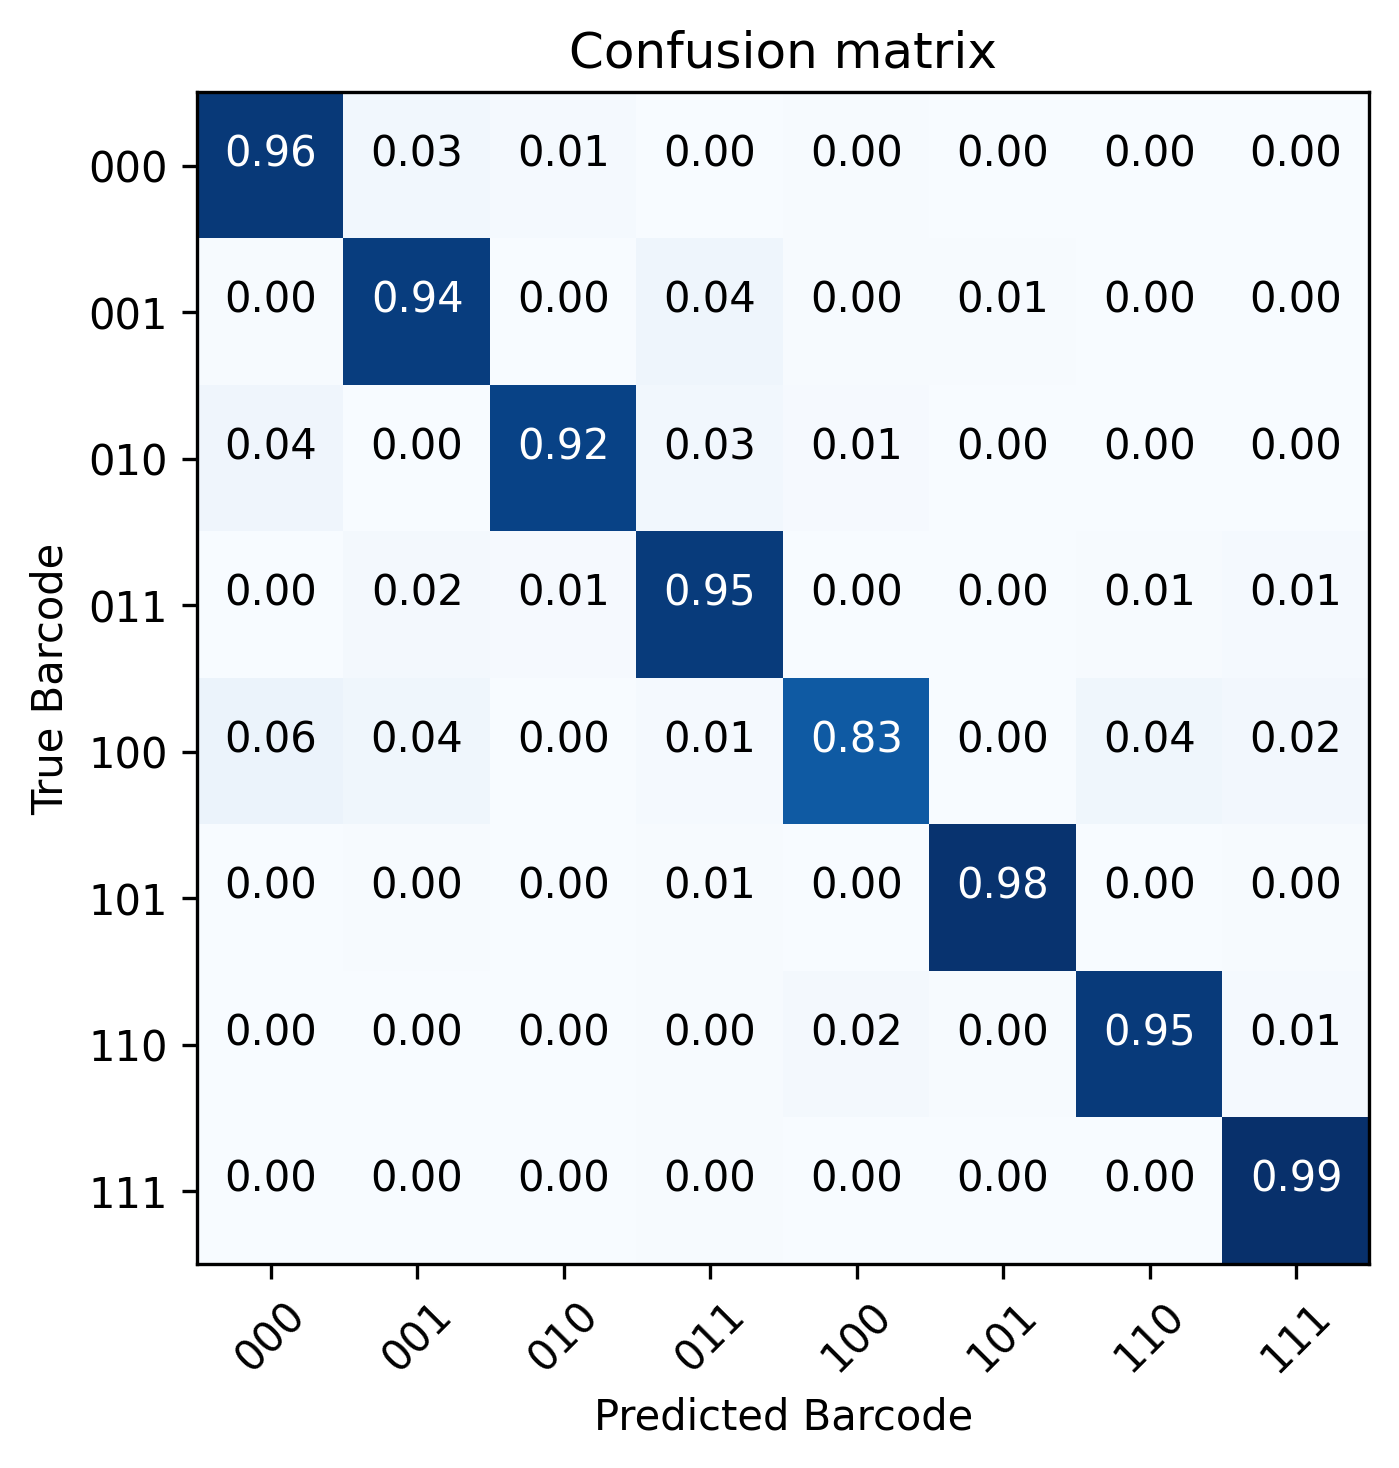

In [21]:
## We will use this function from QuipuNet to obtain the same formatting!
import itertools
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix YupanaNet',
                          cmap=plt.cm.Blues): 
    "This function prints and plots the confusion matrix."
    #cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(dpi=300)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    #pyplot.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' 
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Barcode')
    plt.xlabel('Predicted Barcode')
    plt.savefig("Confusion Matrix YupanaNet")
disp = ConfusionMatrixDisplay(conf_matrix)
barcodeLabels= ['000','001','010','011','100','101','110','111']
plot_confusion_matrix(conf_matrix, classes=barcodeLabels, title="Confusion matrix")


## Retrieving intermediate layer outputs
We will take the the input signals, the layers in between to see if we can observe any pattern on the attention mechanism


In [2]:
results_folder="../../results/PeerReview/RetrieveOutputs/"
out_filters=np.load(results_folder+"out_filters.npy")
out_softmax=np.load(results_folder+"out_softmax.npy")
X_test=np.load(results_folder+"X_test.npy")
y_true_np=np.load(results_folder+"y_true_np.npy")
y_est=np.load("../../results/PeerReview/y_est.npy")

In [91]:


def show_X_and_barcode(X,Y,y_est,idx_init,n_col=4,n_row=8,figsize=(15, 10), suptitle=None):
    fig, axes = plt.subplots(n_row, n_col, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()
    num_signals=n_col*n_row;
    X_plot=X[idx_init:(idx_init+num_signals),:]
    Y_plot=Y[idx_init:(idx_init+num_signals),:]
    y_est_plot=y_est[idx_init:(idx_init+num_signals)]
    
    Y_plot_barcode=[format(np.argmax(row), '03b') for row in Y_plot];
    y_est_plot_barcode=[format(i, '03b') for i in y_est_plot];

    for i in range(num_signals):
        ax = axes[i]
        msg_plot="idx " + str(idx_init+i) + " - Ytrue : " + Y_plot_barcode[i] + " - Yest " + y_est_plot_barcode[i];
        ax.plot(X_plot[i,:])
        ax.set_title(msg_plot)
            
    if suptitle:
        fig.suptitle(suptitle)
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.95 if suptitle else 1.0)
    plt.show()
    
def trace_show_avg_filters_and_softmax(X,Y,filters_output,softmax_output,idx):
    fig, axes = plt.subplots(1, 3,figsize=(10, 5))
    axes = axes.flatten()
    
    axes[0].plot(X[idx,:])
    axes[0].set_title("X")
    
    axes[1].plot(np.mean(filters_output[idx,:,:],axis=1))
    axes[1].set_title("Avg after conv1D")
    
    axes[2].plot(np.mean(softmax_output[idx,:,:],axis=1))
    axes[2].set_title("Avg soft max")
    
    
    msg_plot="idx " + str(idx) + " - Ytrue : " + format(np.argmax(Y[idx,:]), '03b')
    fig.suptitle(msg_plot)
        
    plt.tight_layout()
    #plt.subplots_adjust(top=0.95)
    plt.show()
    
def trace_show_avg_output(X,Y,filters_output,softmax_output,idx): #Here we multiply each softmax with each conv, and then take the mean of all the filters
    fig, axes = plt.subplots(1, 2,figsize=(10, 5))
    axes = axes.flatten()
    
    axes[0].plot(X[idx,:])
    axes[0].set_title("X")
    
    
    aux=np.multiply(filters_output[idx,:,:],softmax_output[idx,:,:])
    
    axes[1].plot(np.mean(aux,axis=1))
    axes[1].set_title("Avg output")
    
    
    msg_plot="idx " + str(idx) + " - Ytrue : " + format(np.argmax(Y[idx,:]), '03b')
    fig.suptitle(msg_plot)
        
    plt.tight_layout()
    #plt.subplots_adjust(top=0.95)
    plt.show()

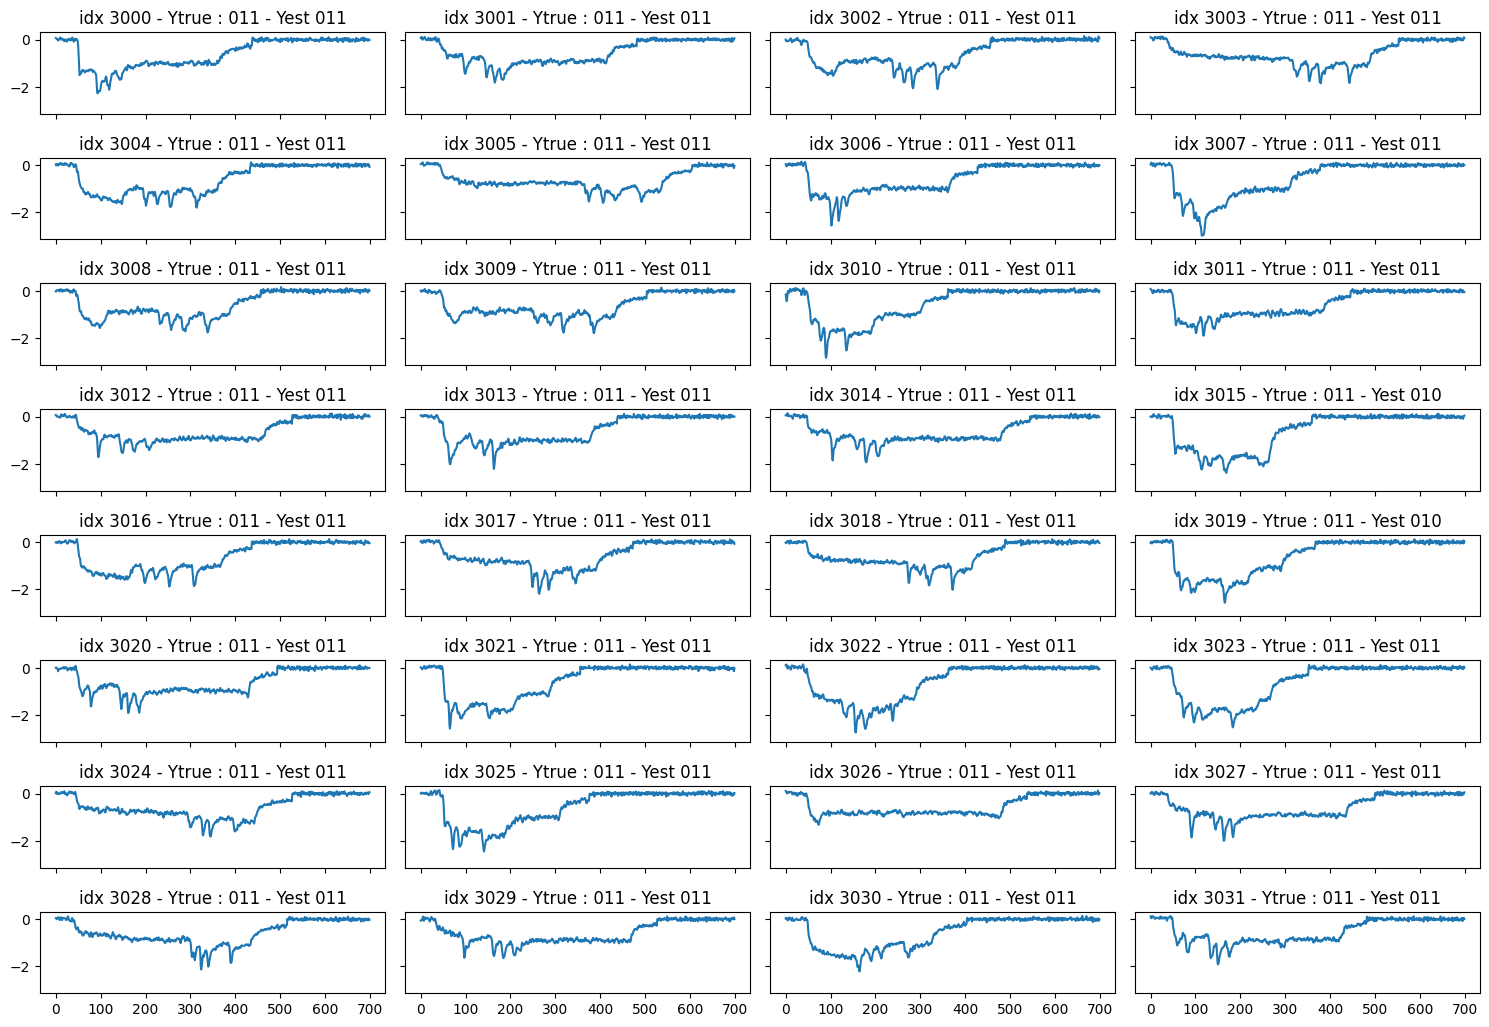

In [96]:

show_X_and_barcode(X_test,y_true_np,y_est,3000)

# 16 is a clear zero. Guessed right
# 312 is a clear 110. Guessed right 
# 920 is a clear 111. Guessed right 
#1674 is a clear 010. Guessed right

## Ones with fold that are hard to see?

#2329 is a 011 hard to see, guess right
#2616 is a 101 hard to see, guess right
#3021 is a 011 hard to see, guess right

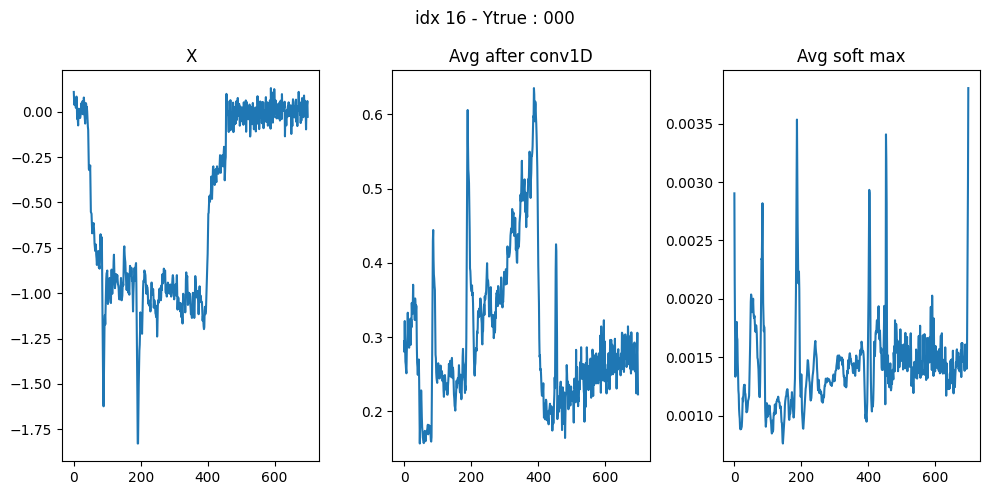

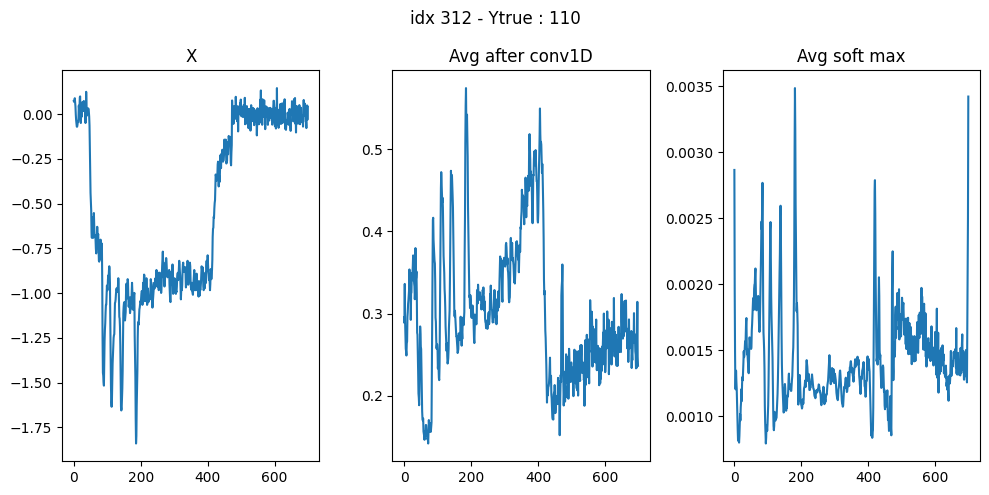

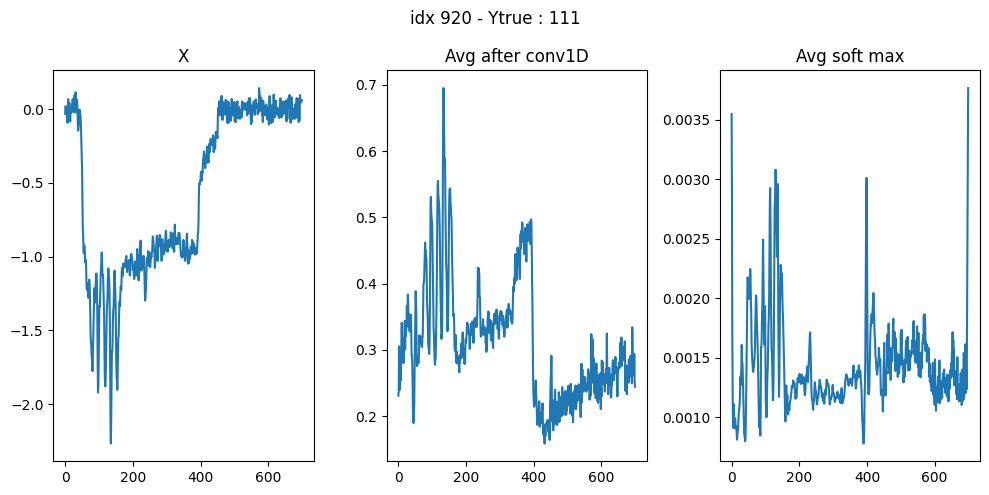

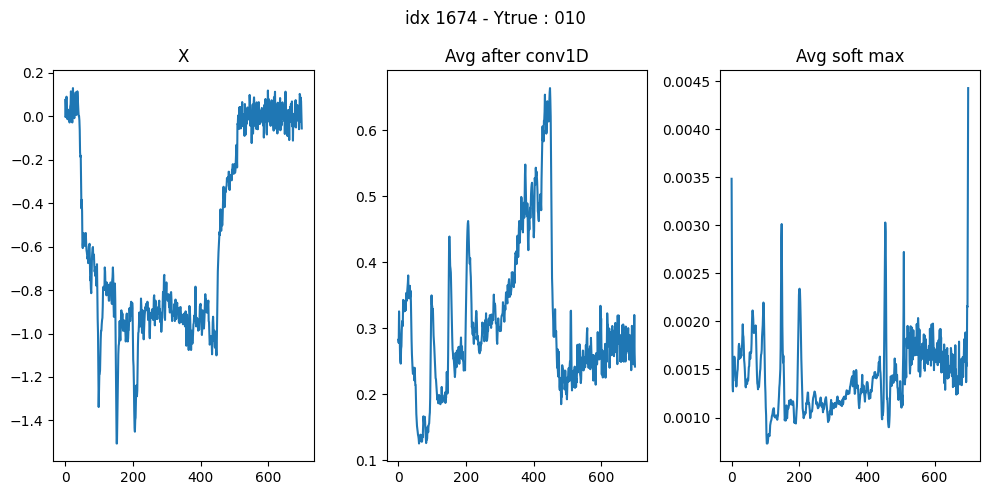

In [90]:
trace_show_avg_filters_and_softmax(X_test,y_true_np,out_filters,out_softmax,16)
trace_show_avg_filters_and_softmax(X_test,y_true_np,out_filters,out_softmax,312)
trace_show_avg_filters_and_softmax(X_test,y_true_np,out_filters,out_softmax,920)
trace_show_avg_filters_and_softmax(X_test,y_true_np,out_filters,out_softmax,1674)

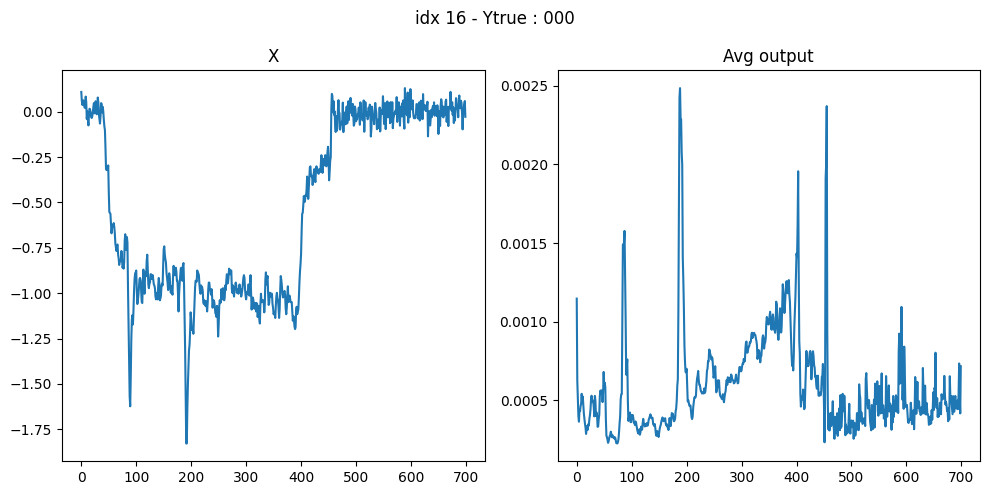

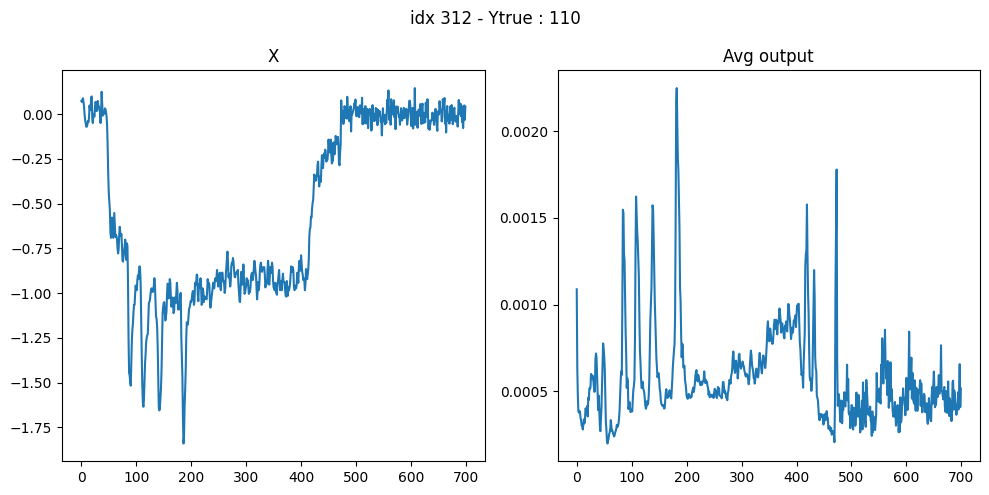

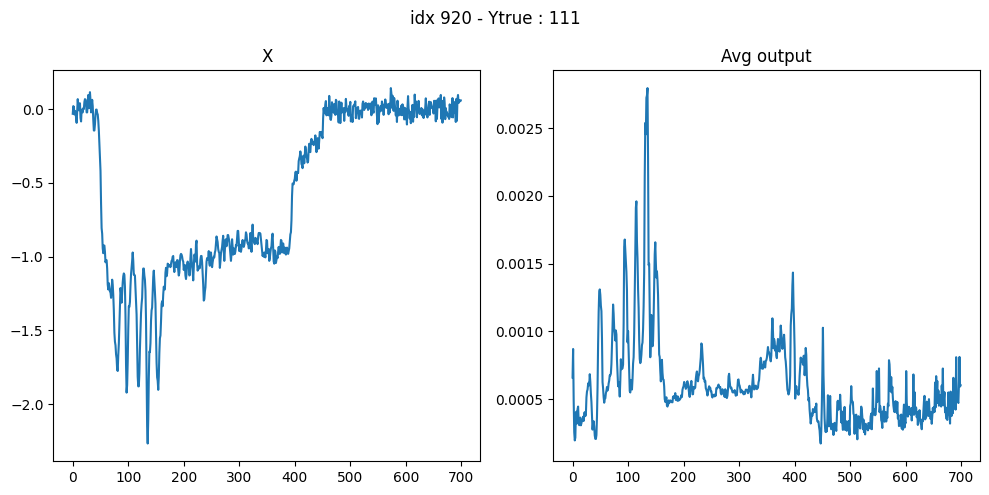

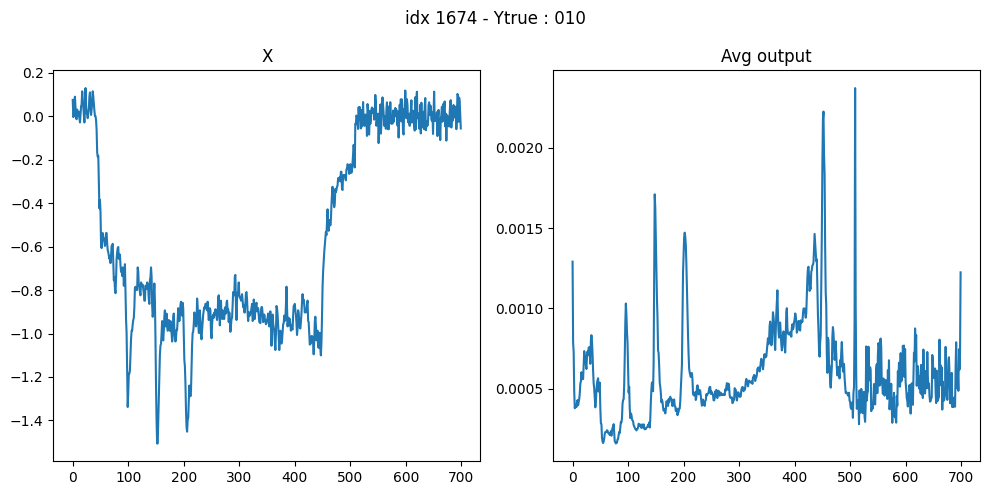

In [93]:
trace_show_avg_output(X_test,y_true_np,out_filters,out_softmax,16)
trace_show_avg_output(X_test,y_true_np,out_filters,out_softmax,312)
trace_show_avg_output(X_test,y_true_np,out_filters,out_softmax,920)
trace_show_avg_output(X_test,y_true_np,out_filters,out_softmax,1674)

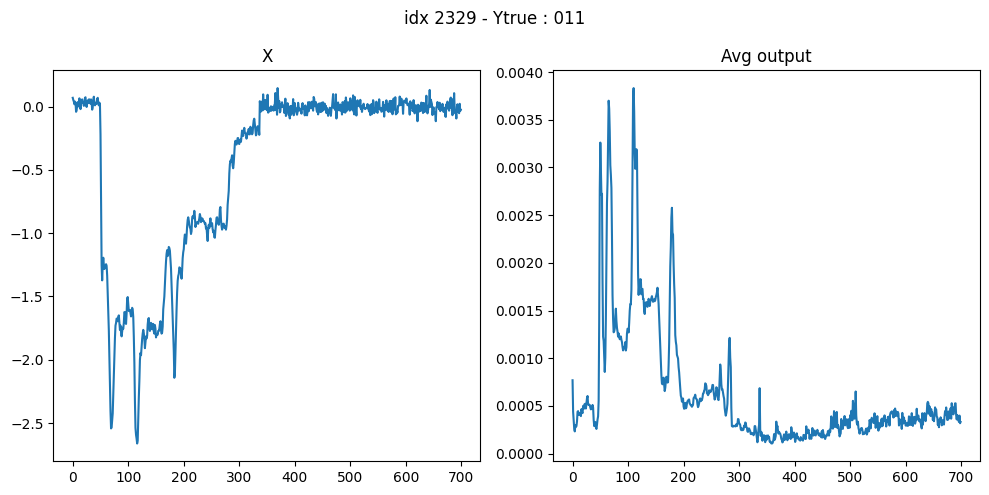

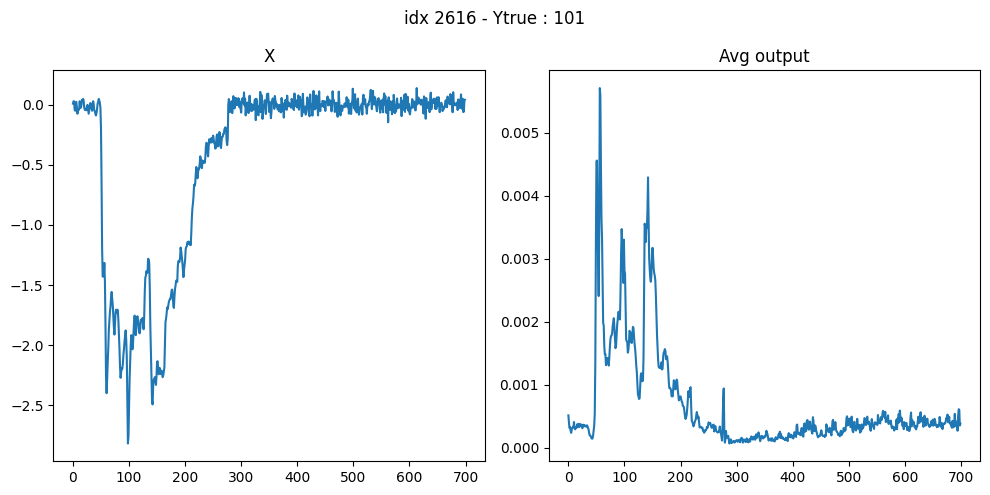

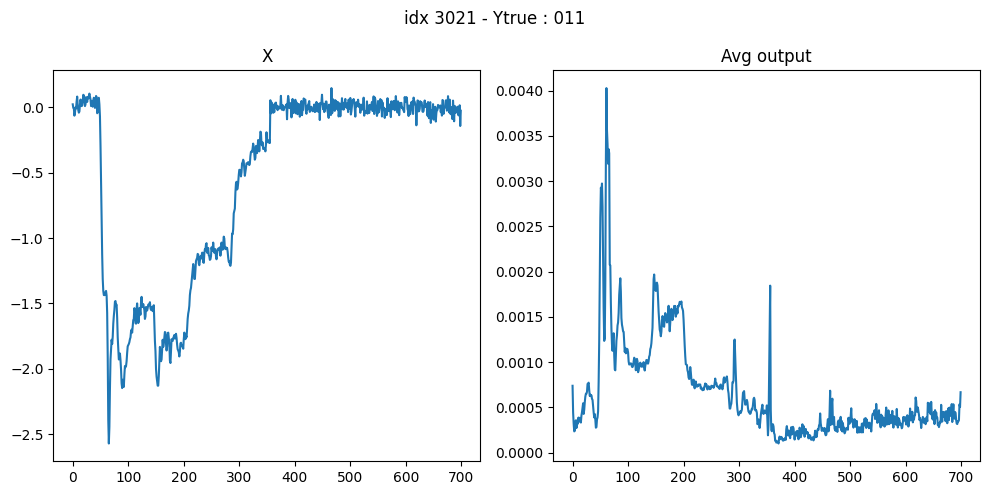

In [97]:
trace_show_avg_output(X_test,y_true_np,out_filters,out_softmax,2329)
trace_show_avg_output(X_test,y_true_np,out_filters,out_softmax,2616)
trace_show_avg_output(X_test,y_true_np,out_filters,out_softmax,3021)

In [18]:

def trace_show_avg_batch(sample_idxs):
    """
    Plots 6 samples in a 4×3 grid:
      - Each sample_i occupies rows 2*i//3*2 and +1 (original above, avg output below).
      - sample_idxs: list of 6 sample indices.
    Uses global X_test, y_true_np, out_filters, out_softmax.
    """
    assert len(sample_idxs) == 6, "Need exactly 6 sample indices"
    
    n_rows, n_cols = 4, 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10), sharex=True,dpi=300)
    axes = axes.reshape(n_rows, n_cols)
    
    for pos, idx in enumerate(sample_idxs):
        col = pos % n_cols
        block = pos // n_cols       # 0 for first 3 samples, 1 for next 3
        row_orig = block * 2        # 0 or 2
        row_avg  = row_orig + 1     # 1 or 3
        
        # Original trace
        ax0 = axes[row_orig, col]
        ax0.plot(X_test[idx], color='black')
        if col == 0:
            ax0.set_ylabel("Original sample")
        true_bin = format(np.argmax(y_true_np[idx]), '03b')
        ax0.set_title(f"Sample {idx} - barcode {true_bin}")
        ax0.set_yticks([])
        
        # Averaged output
        masked = out_filters[idx] * out_softmax[idx]  # shape (700,64)
        avg_out = masked.mean(axis=1)
        
        ax1 = axes[row_avg, col]
        ax1.plot(avg_out, color='blue')
        if col == 0:
            ax1.set_ylabel("Avg out attention block")
        ax1.set_yticks([])
        
        # True label as x-label on avg row (for context)
        
        #ax1.set_xlabel(f"Y_true={true_bin}")
    
    # Set a common x-label on the bottom row
    for col in range(n_cols):
        axes[-1, col].set_xlabel("Time (samples)")
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.92)
    fig.suptitle("Original vs. Averaged output after attention block (6 Samples)", fontsize=16)
    plt.savefig("OrigVsAvg.png")
    plt.show()
    


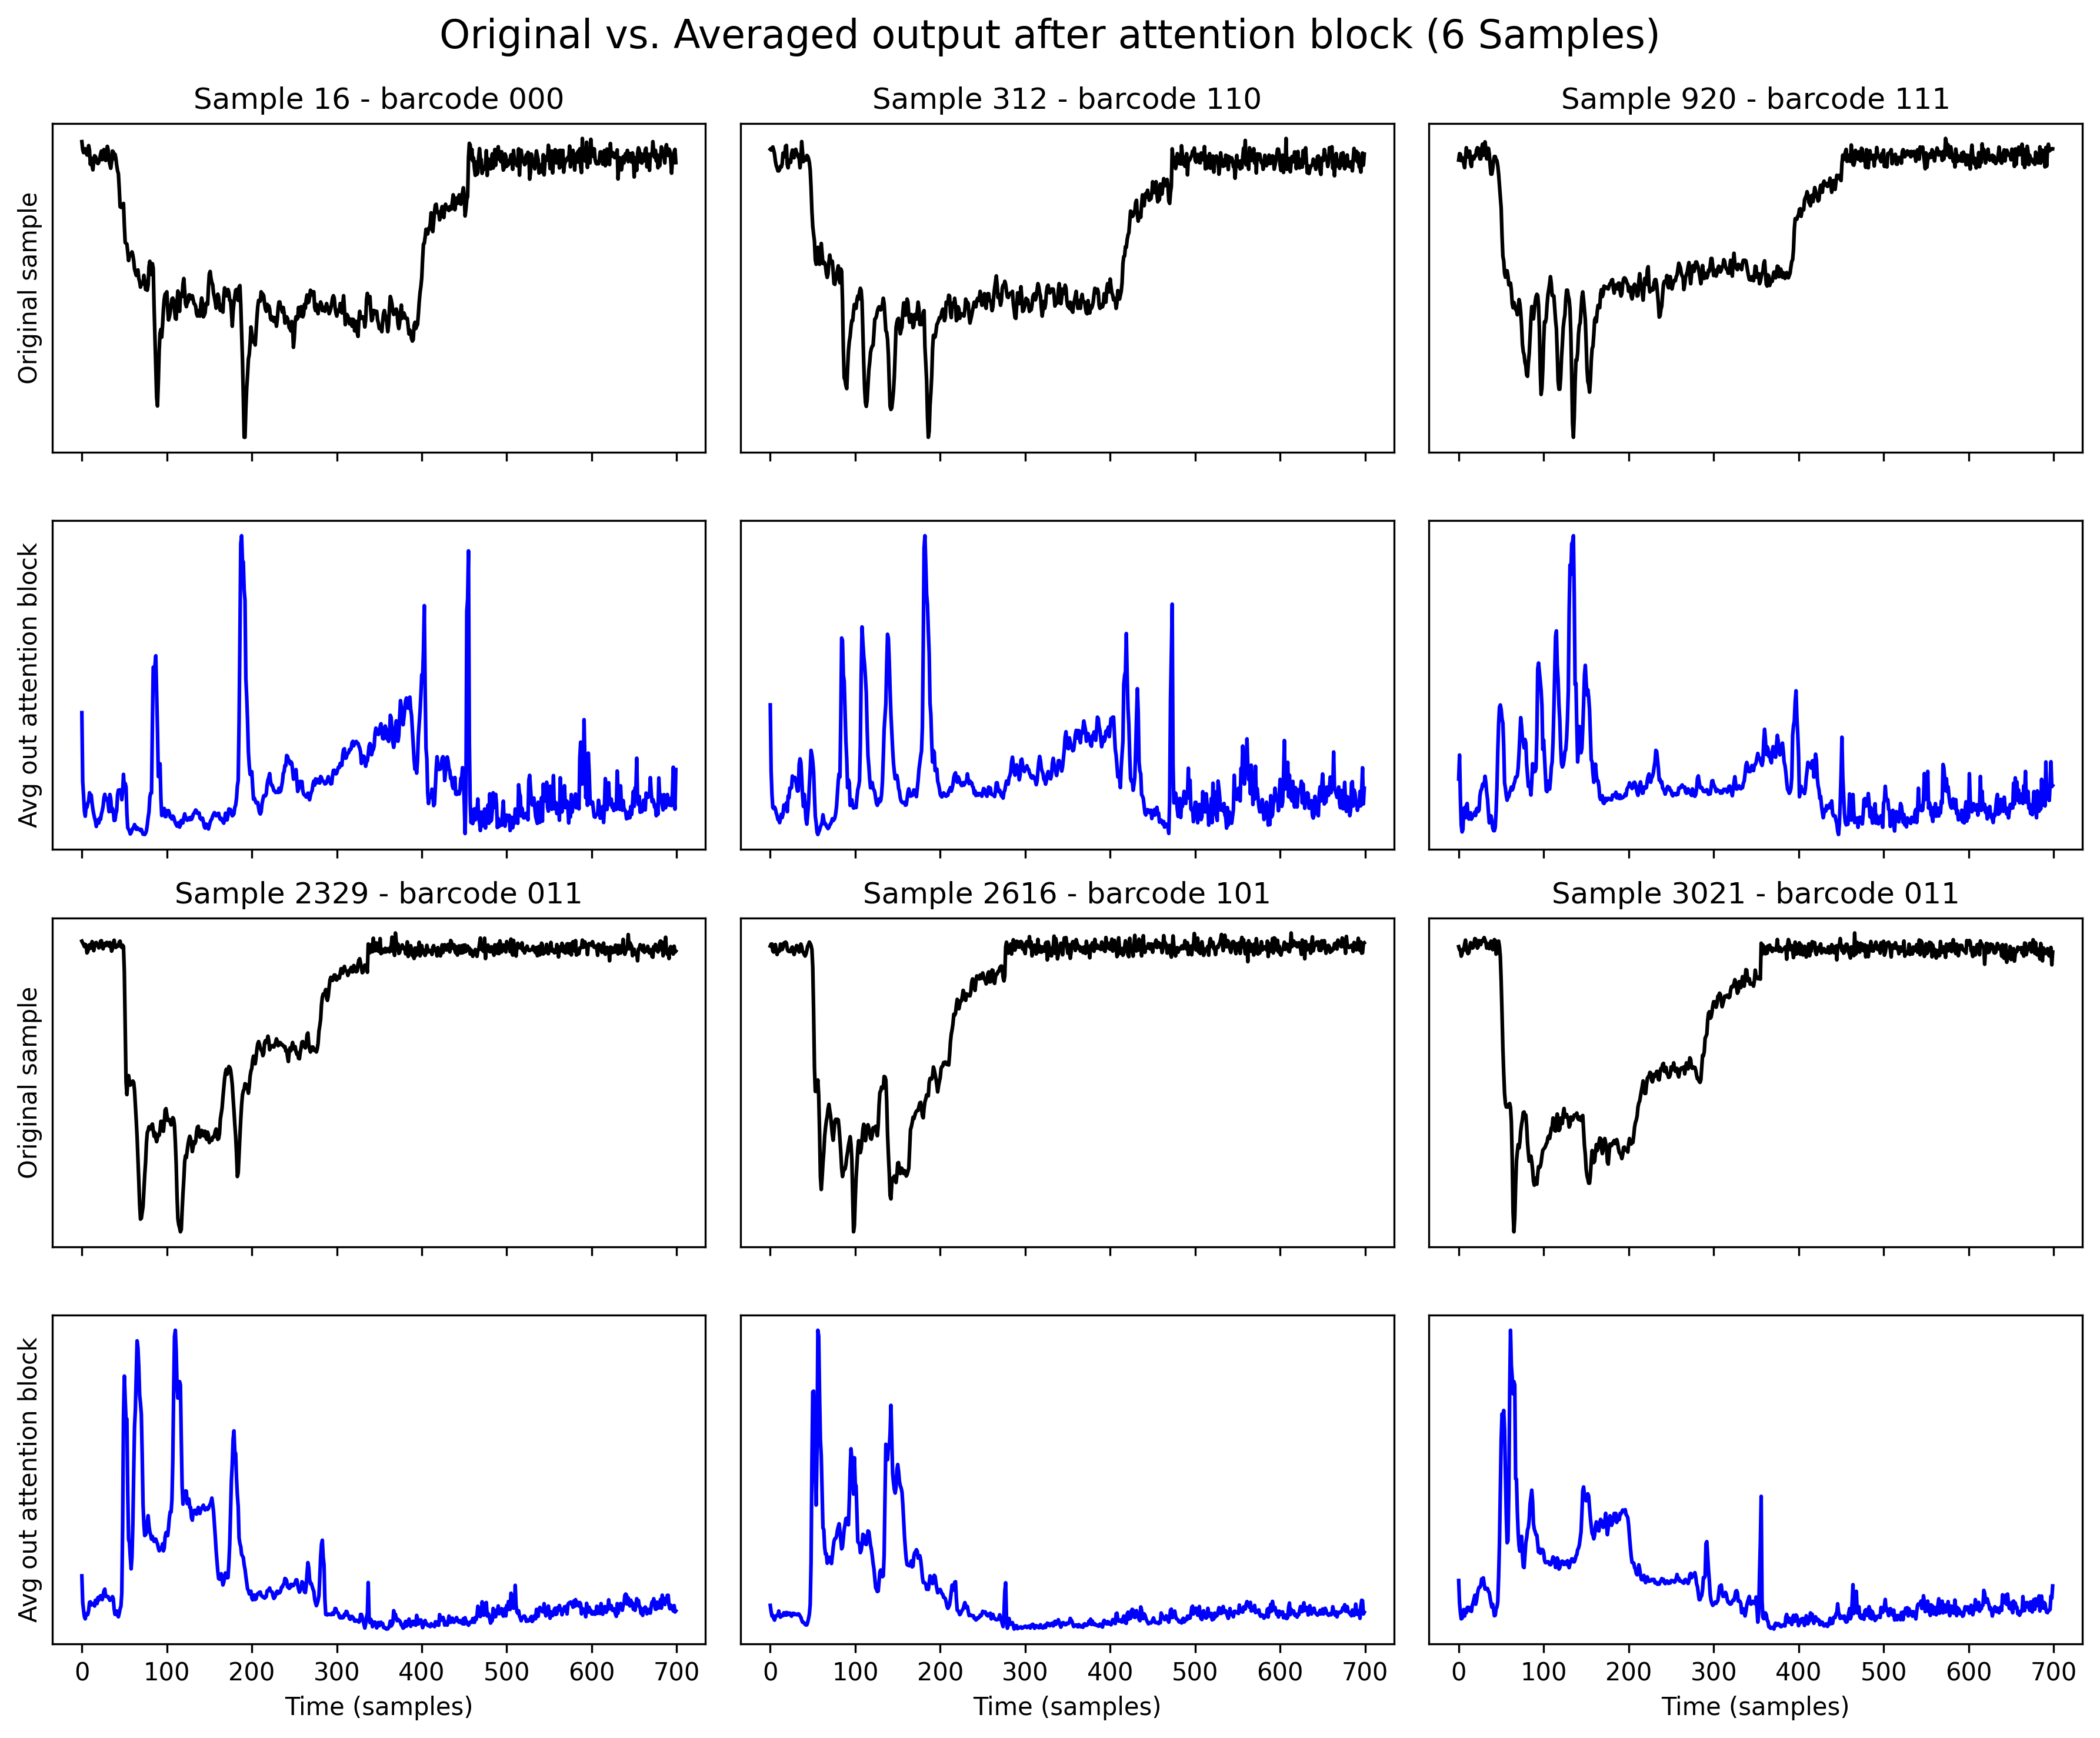

In [19]:
trace_show_avg_batch([16,312,920,2329,2616,3021])

In [5]:
def plot_filter_with_heatmap(sample_idx, filter_idx):
    """
    Plots a single filter response and its corresponding softmax heatmap for a given sample.
    """
    signal = out_filters[sample_idx, :, filter_idx]
    heatmap = out_softmax[sample_idx, :, filter_idx]

    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 4),
                           gridspec_kw={'height_ratios': [3, 1]})
    ax[0].plot(signal, color='blue')
    ax[0].set_ylabel(f'Filter')
    ax[0].set_title(f'Sample {sample_idx} - Filter & Softmax number {filter_idx} Response')

    # 1D heatmap as an image
    ax[1].imshow(heatmap[np.newaxis, :], aspect='auto', cmap='Reds')
    ax[1].set_ylabel(f'Attention')
    ax[1].set_xlabel('Time (samples)')
    plt.tight_layout()
    plt.show()



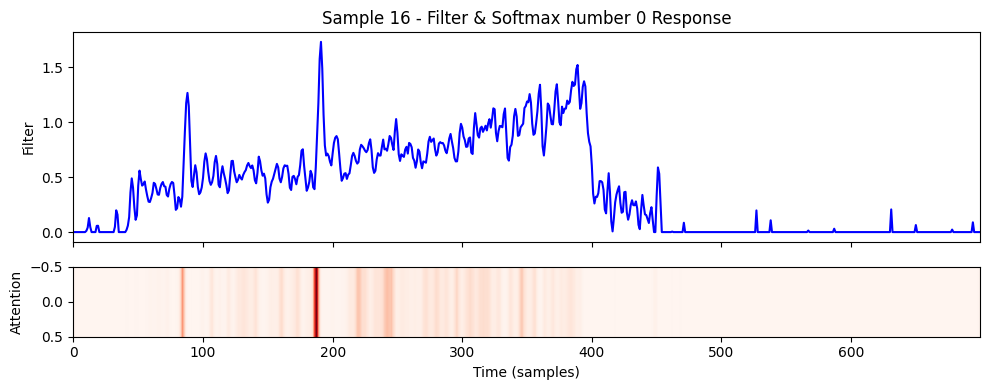

In [15]:
plot_filter_with_heatmap(16, 0)

In [34]:
def plot_sample_with_6filters_aligned(sample_idx, filter_idxs, figsize=(12, 8)):
    """
    Plot 6 filters + attention aligned across three columns, with the original trace centered,
    and short heatmap rows—now with ylabels on both sides and attention labels.
    """
    assert len(filter_idxs) == 6
    barcode = format(np.argmax(y_true_np[sample_idx,:]), '03b')
    
    # Heights: signal rows twice the height of heatmap rows
    block_heights = [2, 0.5] * 3  # 6 rows total

    fig = plt.figure(constrained_layout=False, figsize=figsize,dpi=300)
    gs = fig.add_gridspec(nrows=6, ncols=3,
                          height_ratios=block_heights,
                          hspace=0.1, wspace=0.3)

    # Dummy axis for sharing y-range
    share_ax = fig.add_subplot(gs[0, 0])
    share_ax.axis('off')

    def _plot_filter(col, block_idx, fidx):
        # Signal
        ax_sig = fig.add_subplot(gs[2*block_idx, col], sharey=share_ax)
        sig = out_filters[sample_idx, :, fidx]
        ax_sig.plot(sig, color='blue')
        ax_sig.set_xlim(0,700)
        ax_sig.set_xticks([])
        ax_sig.set_yticks([])
        # Label on left or right
        if col == 0:
            ax_sig.set_ylabel(f"F{fidx}", rotation=0, labelpad=20, va='center')
        else:
            ax_sig.yaxis.set_label_position("right")
            ax_sig.set_ylabel(f"F{fidx}", rotation=0, labelpad=20, va='center')

        # Heatmap
        ax_hm = fig.add_subplot(gs[2*block_idx+1, col])
        hm = out_softmax[sample_idx, :, fidx][np.newaxis, :]
        ax_hm.imshow(hm, aspect='auto', cmap='Reds')
        ax_hm.set_xlim(0,700)
        ax_hm.set_xticks([])
        ax_hm.set_yticks([])
        # Add attention label
        ax_hm.yaxis.set_label_position("right" if col==2 else "left")
        ax_hm.set_ylabel(f"A{fidx}", rotation=0, labelpad=20, va='center')
        if (block_idx==2):
            ax_hm.set_xlabel("Time (samples)")

    # Left column filters 0,1,2
    for i in range(3):
        _plot_filter(col=0, block_idx=i, fidx=filter_idxs[i])

    # Right column filters 3,4,5
    for i in range(3, 6):
        _plot_filter(col=2, block_idx=i-3, fidx=filter_idxs[i])

    # Original trace in center col rows 2–3
    orig_ax = fig.add_subplot(gs[2:4, 1])
    orig_ax.plot(X_test[sample_idx], color='k')
    orig_ax.set_title("Original sample - barcode " + barcode)
    orig_ax.set_xticks([])
    orig_ax.set_yticks([])
    orig_ax.set_xlabel("Time (samples)")
    # Turn off unused panels
    for r in range(6):
        for c in range(3):
            in_left   = (c==0 and (r//2) < 3)
            in_right  = (c==2 and (r//2) < 3)
            in_center = (c==1 and 2 <= r < 4)
            if not (in_left or in_right or in_center):
                ax = fig.add_subplot(gs[r, c])
                ax.axis('off')
    
    
        
    plt.suptitle(f"Sample {sample_idx} — 6 Filters + Attention (Aligned)", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig("FiltersOut.png")
    plt.show()

/local/tmp.4077479/ipykernel_62138/2235183812.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.96])


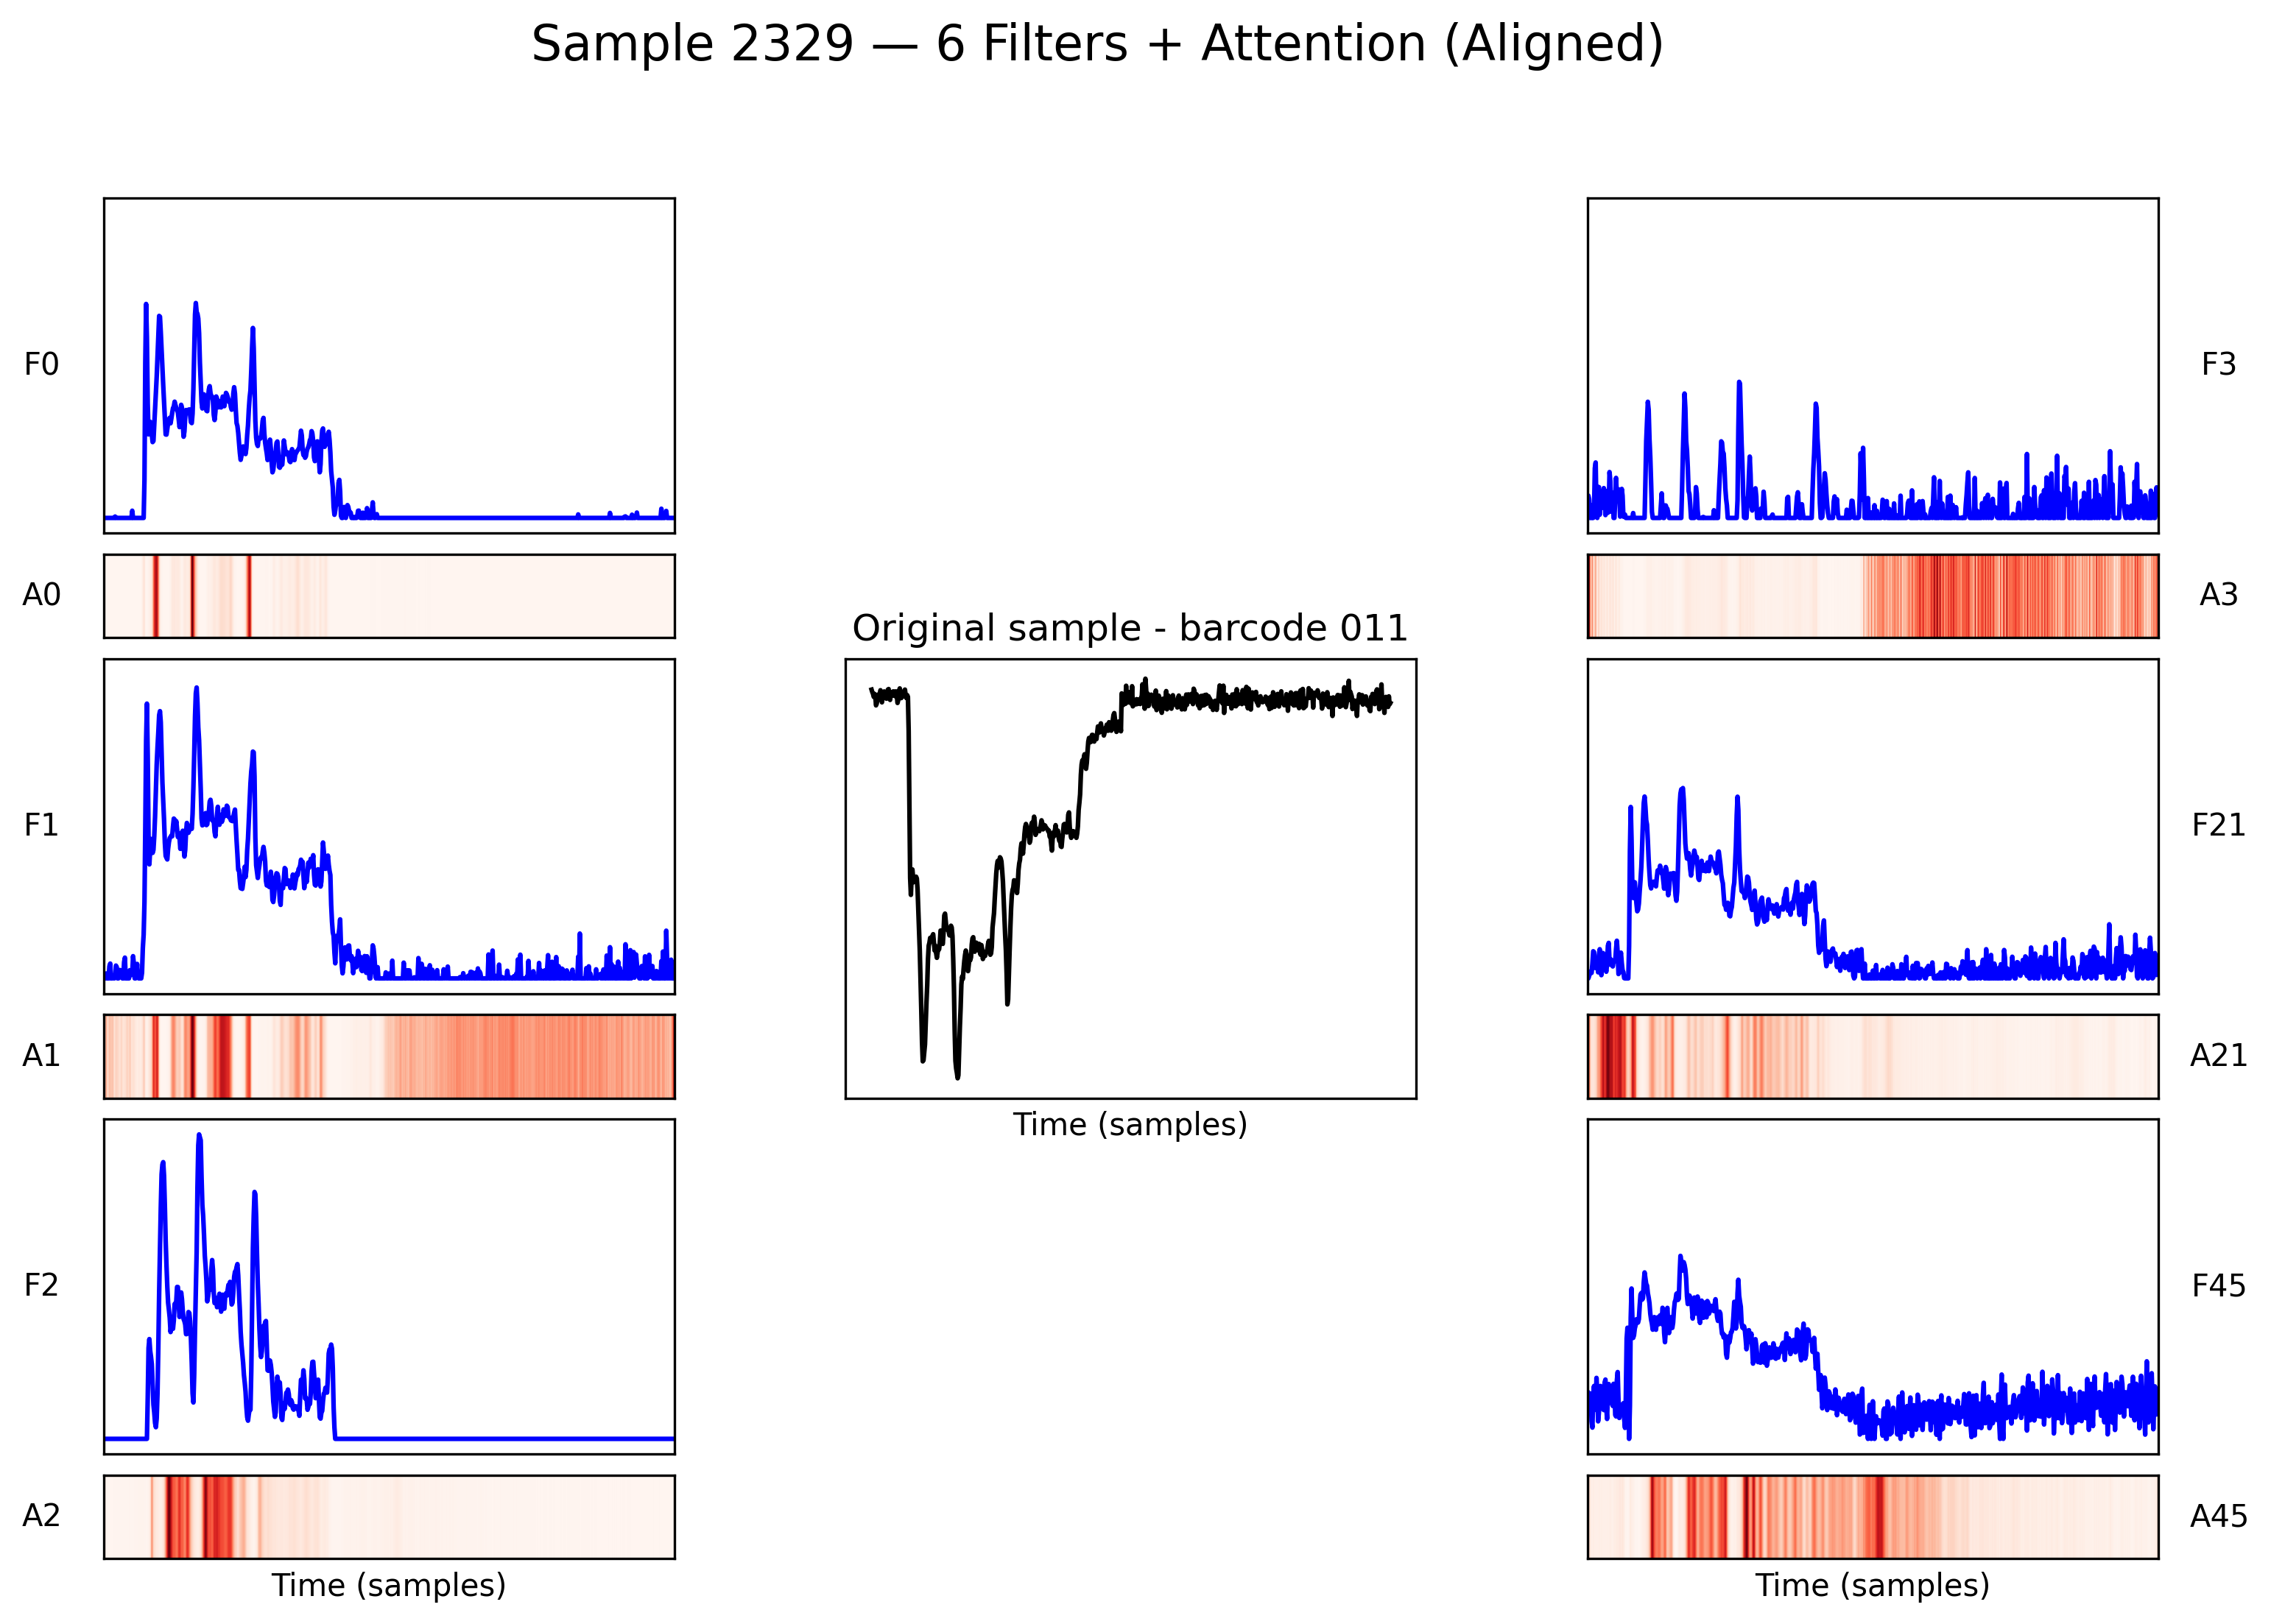

In [40]:
plot_sample_with_6filters_aligned(2329, [0,1,2,3,21,45])

/local/tmp.4077479/ipykernel_62138/2235183812.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.96])


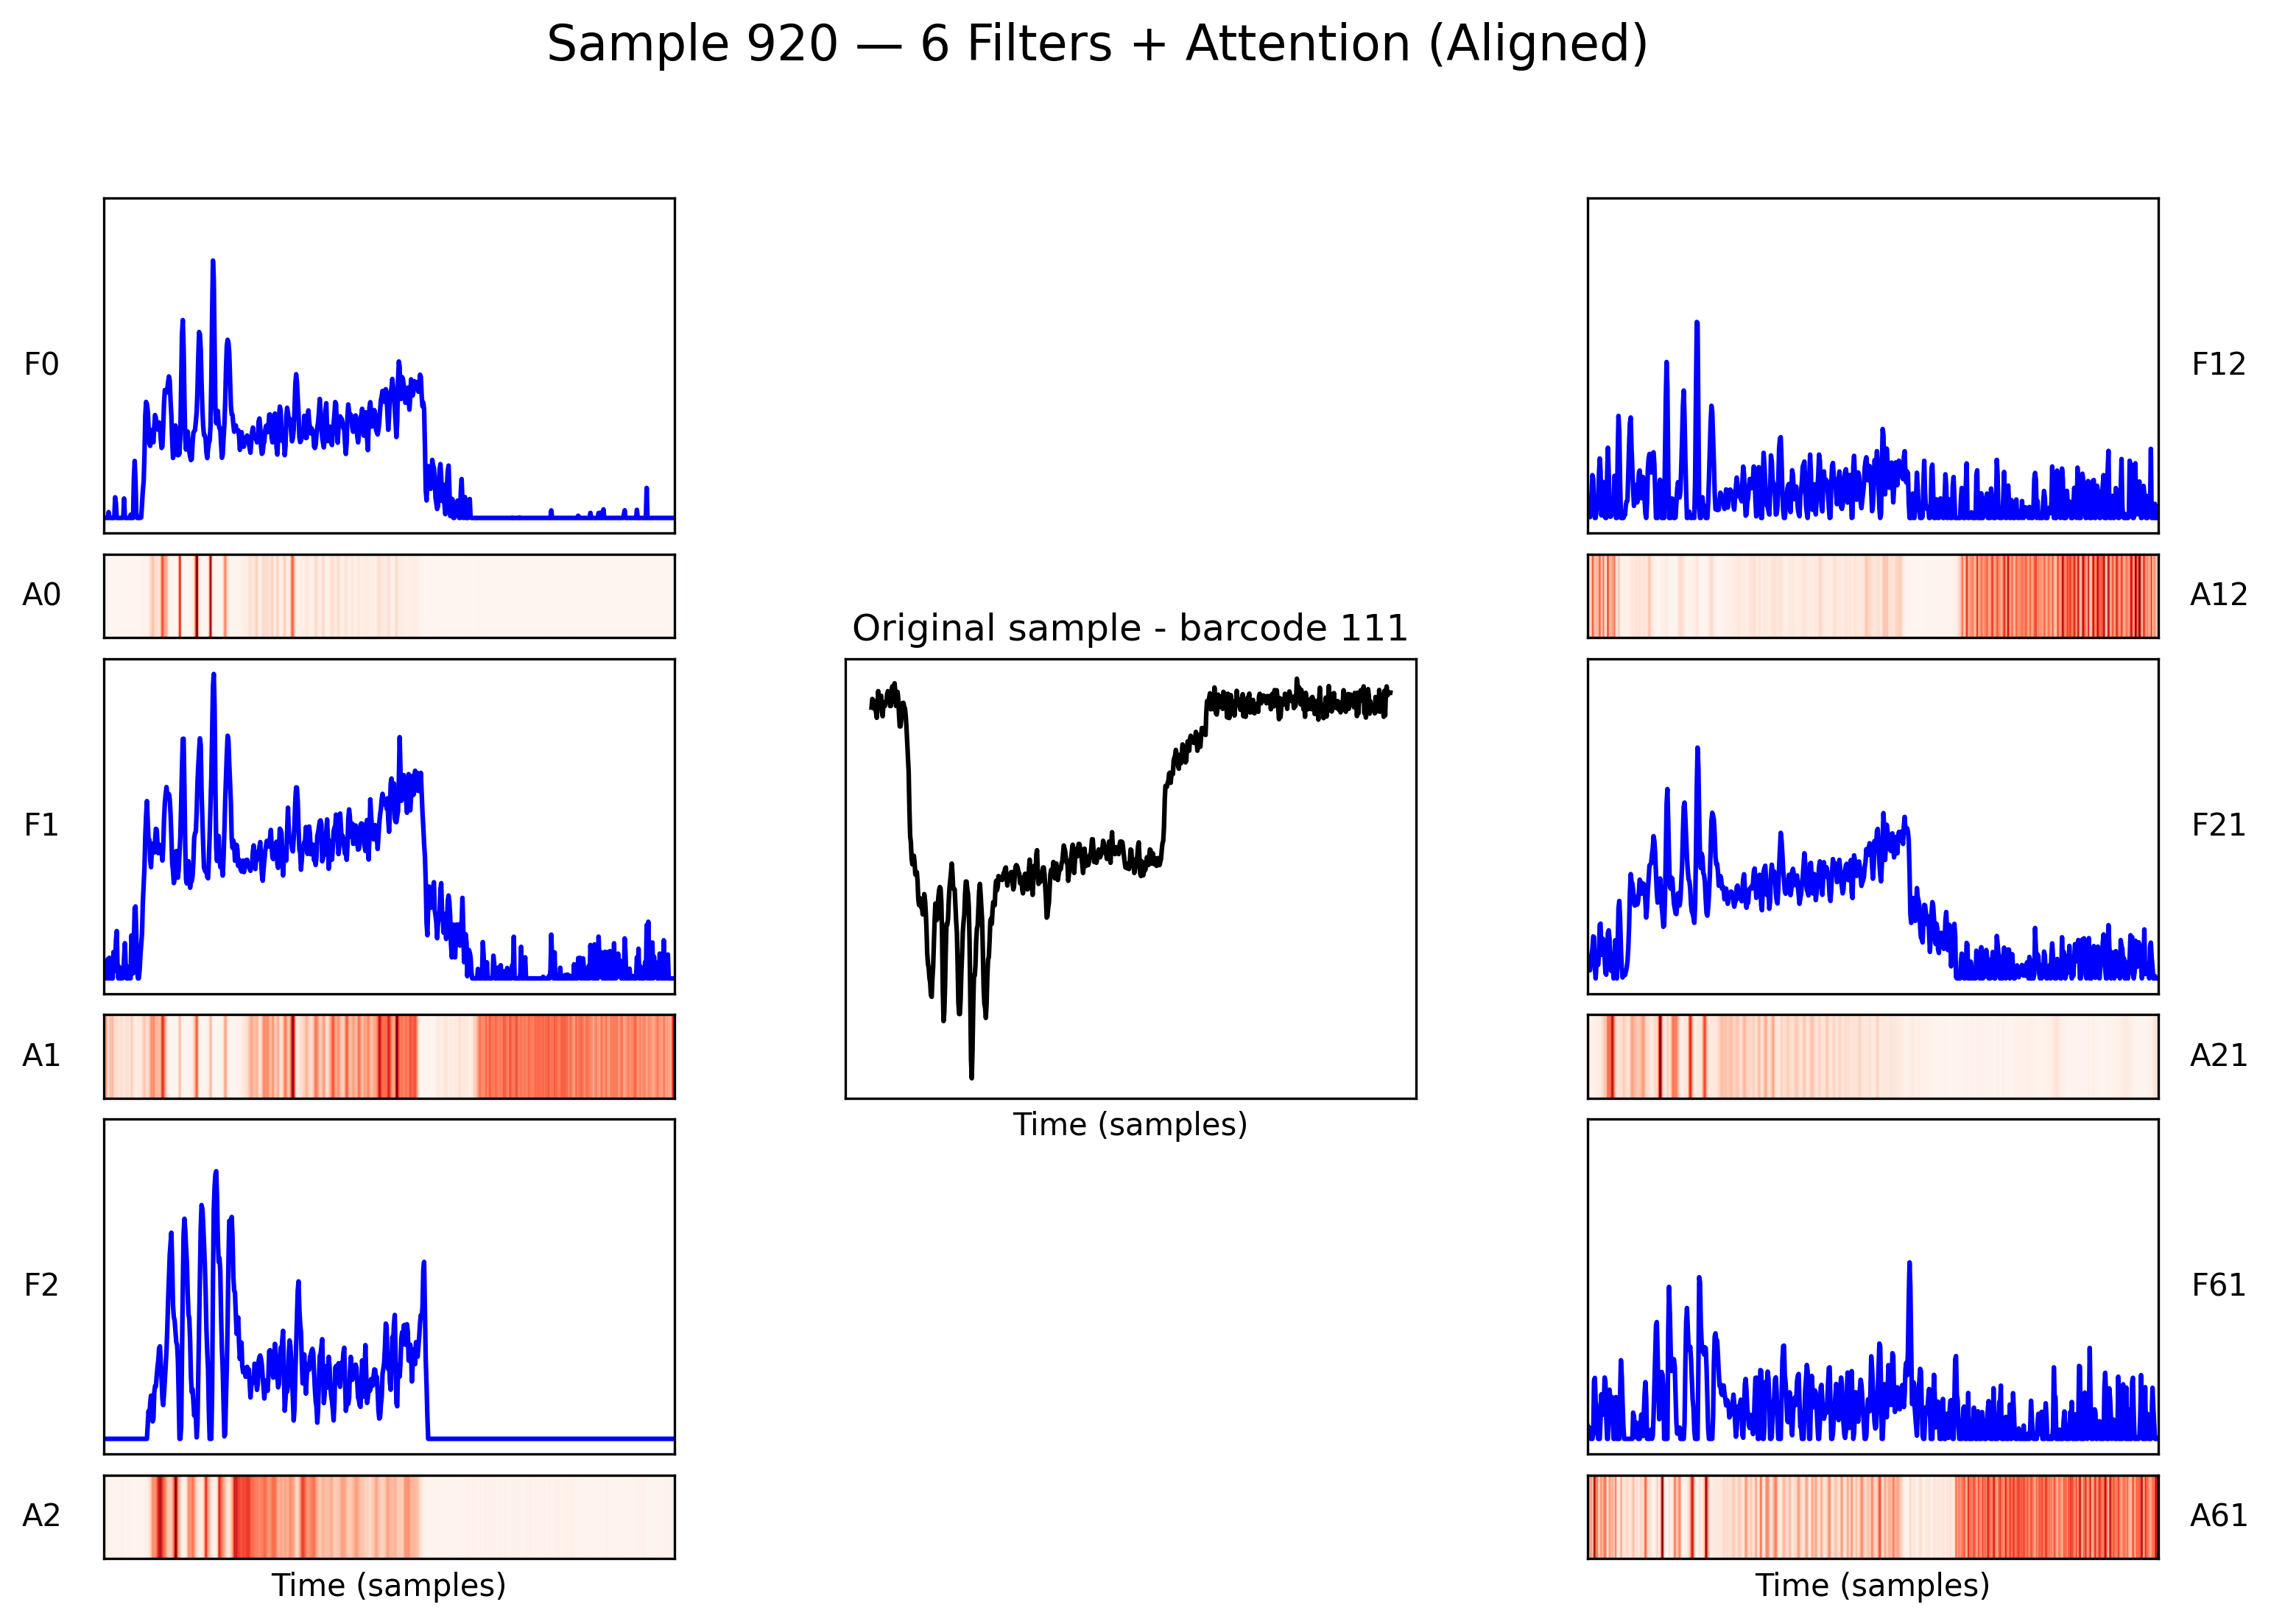

In [39]:
plot_sample_with_6filters_aligned(920, [0,1,2,12,21,61])

## Training for protein detection
I have created the code for protein detection in the folder of ProtDet, and run experiments to check the results I would get with the same training. Here we load them and we get the statistics.

In [3]:
def get_runs_of_experiment(log_filepath,folder):
    common_start=os.path.basename(log_filepath)[:-8];
    df_final=None;
    for dirpath, dnames, fnames in os.walk(folder):
        for f in fnames:
            if (common_start in f) and f.endswith(".csv"):
                if df_final is None:
                    df_final=pd.read_csv(folder+f);
                else:
                    df = pd.read_csv(folder+f);
                    df_final=pd.concat([df_final, df]);
    return df_final

def get_accs(df):
    all_accs=df.iloc[:,:3].to_numpy();
    all_means=np.mean(all_accs,axis=0);
    all_stds=np.std(all_accs,axis=0);
    all_maxs=np.max(all_accs,axis=0);
    train_mean=all_means[0];train_std=all_stds[0];train_max=all_maxs[0];
    valid_mean=all_means[1];valid_std=all_stds[1];valid_max=all_maxs[1];
    test_mean=all_means[2];test_std=all_stds[2];test_max=all_maxs[2];
    return train_mean,train_std,train_max,valid_mean,valid_std,valid_max,test_mean,test_std,test_max

In [8]:
exp_folder="../../results/PeerReview/ProtDet/"
log_filename=exp_folder+"20250420_19-35-21_YupanaNetProtDet_log.txt"
df=get_runs_of_experiment(log_filename,exp_folder)

In [13]:
train_mean,train_std,train_max,valid_mean,valid_std,valid_max,test_mean,test_std,test_max=get_accs(df)
print(test_mean)
print(test_std)
print(test_max)

0.9783920288085938
0.0021608350487580816
0.9821016192436218
